<a href="https://colab.research.google.com/github/VictorPortolani/am_turma5_prova/blob/main/prova_pratica_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prova Prática 14:  Classificação da Zona Extrema do Indicador Técnico RSI

## Instalação e Importação das Bibliotecas

In [405]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

In [406]:
import pandas as pd # organizar arrays
import numpy as np #funções matemáticas complexos
import matplotlib.pyplot as plt #plotar funções matemáticas complexas
import seaborn as sns # vizualizar gráficos
import plotly.express as px #expor a biblioteca

In [407]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Fazendo a requisição da API

**Ponto Importante:** O período de data possível de se fazer requisão foi até no máximo 1999-11-12, iniciando de ordem decrescente em 2026-10-08

In [408]:
import requests
import time

API_KEY = '8YT5F7GZA58UZOIT'
EMPRESA = 'IBM' #Empresa IBM

# Dicionário contendo apenas as URLs a serem consultadas
endpoints = {
    'cotacoes': f'https://www.alphavantage.co/query?function=TIME_SERIES_WEEKLY&symbol={EMPRESA}&apikey={API_KEY}',
    'rsi': f'https://www.alphavantage.co/query?function=RSI&symbol={EMPRESA}&interval=weekly&time_period=14&series_type=close&apikey={API_KEY}'
}

respostas = {}

for nome, url in endpoints.items():
    sucesso = False
    tentativas = 0

    while not sucesso and tentativas < 5:
        print(f"Requisitando {nome} (tentativa {tentativas + 1})...")
        resposta = requests.get(url).json()

        # Verifica se a API retornou o aviso de bloqueio por limite de requisições por minuto
        if 'Note' in resposta or 'Information' in resposta:
            print("Limite de requisições atingido. Aguardando 60 segundos para liberar a cota...")
            time.sleep(60)
            tentativas += 1
        elif 'Error Message' in resposta:
            print(f"Erro na requisição de {nome}: {resposta['Error Message']}")
            break
        else:
            respostas[nome] = resposta
            print(f"{nome.capitalize()} obtido com sucesso.")
            sucesso = True
            # Pausa de 15 segundos entre uma URL e outra para não disparar o teto da chave gratuita
            time.sleep(15)

# As respostas brutas em JSON ficam salvas no dicionário
resposta_cotacoes = respostas.get('cotacoes')
resposta_rsi = respostas.get('rsi')

Requisitando cotacoes (tentativa 1)...
Cotacoes obtido com sucesso.
Requisitando rsi (tentativa 1)...
Rsi obtido com sucesso.


In [409]:
base_semanal = pd.DataFrame(resposta_cotacoes['Weekly Time Series']).T
base_semanal

,1. open,2. high,3. low,4. close,5. volume
2026-10-08,222.3000,227.3050,217.7950,226.6100,23082088
2026-10-02,222.5000,234.2700,218.6000,222.6400,30268686
2026-09-25,231.9900,237.8600,225.1900,225.5100,25845556
2026-09-18,249.4100,251.8150,229.3800,229.5500,36837088
2026-09-11,232.9500,243.6300,230.2000,243.2900,21932204
...,...,...,...,...,...
1999-12-10,113.0000,122.1200,107.5600,109.0000,58626000
1999-12-03,104.9400,112.8700,102.1200,111.8700,37670000
1999-11-26,105.5000,109.8700,101.8100,105.0000,37165600
1999-11-19,96.0000,105.1200,92.6200,103.9400,61550800


In [410]:
if 'Technical Analysis: RSI' in resposta_rsi:
    base_rsi = pd.DataFrame(resposta_rsi['Technical Analysis: RSI']).T
    display(base_rsi)
else:
    print("Não foi possível criar o DataFrame do RSI devido ao limite da API Alpha Vantage.")
    print("Retorno da API:", resposta_rsi)

,RSI
2026-10-08,44.5285
2026-10-02,43.0175
2026-09-25,43.8187
2026-09-18,44.9121
2026-09-11,48.7541
...,...
2000-03-17,61.0291
2000-03-10,56.9383
2000-03-03,60.3436
2000-02-25,60.3436


## Alinhar DataFrames com o índice(Data)

In [411]:
# 1. Transformar as respostas em DataFrames orientados pelo índice (as datas)
df_cotacoes = pd.DataFrame.from_dict(resposta_cotacoes['Weekly Time Series'], orient='index')
df_rsi = pd.DataFrame.from_dict(resposta_rsi['Technical Analysis: RSI'], orient='index')

In [412]:
# 2. Converter os índices (que chegam como string) para datetime
df_cotacoes.index = pd.to_datetime(df_cotacoes.index)
df_rsi.index = pd.to_datetime(df_rsi.index)

In [413]:
# 3. Converter os valores das colunas para numérico (float)
df_cotacoes = df_cotacoes.astype(float)
df_rsi = df_rsi.astype(float)

In [414]:
# 4. Renomear as colunas das cotações para facilitar o uso no ML
df_cotacoes.columns = ['open', 'high', 'low', 'close', 'volume']
df_rsi.columns = ['rsi']

In [415]:
# 5. ALINHAMENTO: Realizar o inner join
# O 'inner' descarta automaticamente as 14 semanas iniciais onde não existe RSI,
# mantendo apenas as datas que existem em AMBAS as requisições.
df_final = df_cotacoes.join(df_rsi, how='inner')

In [416]:
# 6. Ordenar do mais antigo para o mais recente (essencial para séries temporais)
df_final = df_final.sort_index()

In [417]:
# Verificação
print(f"Total de linhas alinhadas: {len(df_final)}") # Retornará 1133 linhas
print(f"Data inicial: {df_final.index.min().strftime('%Y-%m-%d')}") # 2005-04-22
print(f"Data final:   {df_final.index.max().strftime('%Y-%m-%d')}") # Data mais recente
display(df_final)

Total de linhas alinhadas: 1391
Data inicial: 2000-02-18
Data final:   2026-10-08


,open,high,low,close,volume,rsi
2000-02-18,116.00,118.870,111.500,112.50,26599300.0,65.9050
2000-02-25,112.00,113.440,104.940,108.00,34514300.0,60.3436
2000-03-03,104.62,110.000,99.500,108.00,51128300.0,60.3436
2000-03-10,109.94,111.000,101.000,105.25,42586200.0,56.9383
2000-03-17,104.00,111.690,102.500,110.00,36990400.0,61.0291
...,...,...,...,...,...,...
2026-09-11,232.95,243.630,230.200,243.29,21932204.0,48.7541
2026-09-18,249.41,251.815,229.380,229.55,36837088.0,44.9121
2026-09-25,231.99,237.860,225.190,225.51,25845556.0,43.8187
2026-10-02,222.50,234.270,218.600,222.64,30268686.0,43.0175


## Construção do Target

In [418]:
# 1. Garante que os dados estão ordenados cronologicamente (essencial para o shift)
df_final = df_final.sort_index()

In [419]:
# 2. Obtém o RSI da semana seguinte (t+1)
df_final['rsi_next'] = df_final['rsi'].shift(-1)

In [420]:
# 3. Define as condições lógicas para cada zona
condicoes = [
    df_final['rsi_next'] > 70,                                      # Classe 2
    df_final['rsi_next'] < 30,                                      # Classe 0
    (df_final['rsi_next'] >= 30) & (df_final['rsi_next'] <= 70)    # Classe 1
]
valores = [2, 0, 1]

In [421]:
# 4. Cria a coluna alvo 'target_rsi_zone'
df_final['target_rsi_zone'] = np.select(condicoes, valores, default=np.nan)

In [422]:
# 5. Remove a última linha (que não possui t+1 futuro e gera NaN) e ajusta o tipo
df_final = df_final.dropna(subset=['target_rsi_zone'])
df_final['target_rsi_zone'] = df_final['target_rsi_zone'].astype(int)

In [423]:
df_final

,open,high,low,close,volume,rsi,rsi_next,target_rsi_zone
2000-02-18,116.00,118.870,111.50,112.50,26599300.0,65.9050,60.3436,1
2000-02-25,112.00,113.440,104.94,108.00,34514300.0,60.3436,60.3436,1
2000-03-03,104.62,110.000,99.50,108.00,51128300.0,60.3436,56.9383,1
2000-03-10,109.94,111.000,101.00,105.25,42586200.0,56.9383,61.0291,1
2000-03-17,104.00,111.690,102.50,110.00,36990400.0,61.0291,68.2838,1
...,...,...,...,...,...,...,...,...
2026-09-04,232.73,238.290,229.10,234.89,22094648.0,46.1385,48.7541,1
2026-09-11,232.95,243.630,230.20,243.29,21932204.0,48.7541,44.9121,1
2026-09-18,249.41,251.815,229.38,229.55,36837088.0,44.9121,43.8187,1
2026-09-25,231.99,237.860,225.19,225.51,25845556.0,43.8187,43.0175,1


In [424]:
# 6. Remove a coluna auxiliar temporária
df_final = df_final.drop(columns=['rsi_next'])

In [425]:
# Conferência da contagem de cada classe
print(df_final['target_rsi_zone'].value_counts())

target_rsi_zone
1    1273
2      85
0      32
Name: count, dtype: int64


In [426]:
df_final

,open,high,low,close,volume,rsi,target_rsi_zone
2000-02-18,116.00,118.870,111.50,112.50,26599300.0,65.9050,1
2000-02-25,112.00,113.440,104.94,108.00,34514300.0,60.3436,1
2000-03-03,104.62,110.000,99.50,108.00,51128300.0,60.3436,1
2000-03-10,109.94,111.000,101.00,105.25,42586200.0,56.9383,1
2000-03-17,104.00,111.690,102.50,110.00,36990400.0,61.0291,1
...,...,...,...,...,...,...,...
2026-09-04,232.73,238.290,229.10,234.89,22094648.0,46.1385,1
2026-09-11,232.95,243.630,230.20,243.29,21932204.0,48.7541,1
2026-09-18,249.41,251.815,229.38,229.55,36837088.0,44.9121,1
2026-09-25,231.99,237.860,225.19,225.51,25845556.0,43.8187,1


## **Preditores:** Retorno semanal e SMA

In [427]:
# 1. Definir o período da SMA
janela_sma = 20

In [428]:
# 2. Preditor 1: Retorno semanal do preço de fechamento
df_final['retorno_semanal'] = df_final['close'].pct_change()

In [429]:
# 3. Preditor 2: Variação percentual da Média Móvel Simples (SMA)
df_final['sma'] = df_final['close'].rolling(window=janela_sma).mean()
df_final['variacao_sma'] = df_final['sma'].pct_change()

In [430]:
# 4. Remover linhas com NaN resultantes do cálculo inicial da média móvel e do retorno
df_final = df_final.dropna(subset=['retorno_semanal', 'variacao_sma', 'target_rsi_zone'])

In [431]:
# 5. Definição explícita de X (preditores) e y (alvo) para o modelo de ML
X = df_final[['retorno_semanal', 'variacao_sma']]
y = df_final['target_rsi_zone']

In [432]:
print("Dimensões dos preditores (X):", X.shape)
print("Distribuição do alvo (y):", y.shape)
print(y.value_counts())

Dimensões dos preditores (X): (1370, 2)
Distribuição do alvo (y): (1370,)
target_rsi_zone
1    1253
2      85
0      32
Name: count, dtype: int64


In [433]:
df_final

,open,high,low,close,volume,rsi,target_rsi_zone,retorno_semanal,sma,variacao_sma
2000-07-07,108.75,109.870,100.00,105.06,38608400.0,48.1566,1,-0.041073,110.3895,-0.003359
2000-07-14,104.69,105.940,101.00,103.94,25072200.0,47.2134,1,-0.010661,110.1865,-0.001839
2000-07-21,104.44,117.810,101.00,114.75,52881600.0,56.1424,1,0.104002,110.5240,0.003063
2000-07-28,114.12,115.620,108.87,111.81,28454700.0,53.4922,1,-0.025621,110.8520,0.002968
2000-08-04,110.50,116.500,110.06,115.87,24015800.0,56.5430,1,0.036312,111.1455,0.002648
...,...,...,...,...,...,...,...,...,...,...
2026-09-04,232.73,238.290,229.10,234.89,22094648.0,46.1385,1,-0.002971,247.4020,-0.003741
2026-09-11,232.95,243.630,230.20,243.29,21932204.0,48.7541,1,0.035761,247.9675,0.002286
2026-09-18,249.41,251.815,229.38,229.55,36837088.0,44.9121,1,-0.056476,247.8350,-0.000534
2026-09-25,231.99,237.860,225.19,225.51,25845556.0,43.8187,1,-0.017600,247.6225,-0.000857


## LabelEncoder e Divisão de Treino e Testes

In [434]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [435]:
# 1. Separar as variáveis preditoras e a variável alvo
X = df_final[['retorno_semanal', 'variacao_sma']]
y_bruto = df_final['target_rsi_zone']

In [436]:
# 2. Codificar o target com LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_bruto)

print("Mapeamento do LabelEncoder:")
for cod, rotulo in enumerate(label_encoder.classes_):
    print(f"  Classe codificada {cod} -> Rótulo original {rotulo}")

Mapeamento do LabelEncoder:
  Classe codificada 0 -> Rótulo original 0
  Classe codificada 1 -> Rótulo original 1
  Classe codificada 2 -> Rótulo original 2


In [437]:
# 3. Padronizar todos os preditores com StandardScaler ANTES da divisão
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [438]:
# 4. Dividir em 80% treino e 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    shuffle=False  # Mantém a ordem temporal dos dados
)

In [439]:
# Verificação dos conjuntos resultantes
print("Formato X_train:", X_train.shape)
print("Formato X_test: ", X_test.shape)
print("Classes mapeadas:", label_encoder.classes_)

Formato X_train: (1096, 2)
Formato X_test:  (274, 2)
Classes mapeadas: [0 1 2]


## Modelo GaussianNB, Matriz de Confusão 3x3 e Acurácia

In [440]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score
)

In [441]:
# 1. Ajustar o modelo GaussianNB com os dados de treino
modelo_gnb = GaussianNB()
modelo_gnb.fit(X_train, y_train)

GaussianNB()

In [442]:
# 2. Gerar predições para a partição de teste
y_pred = modelo_gnb.predict(X_test)

In [443]:
# 3. Construir e exibir a Matriz de Confusão Multiclasse 3x3
labels_ordem = [0, 1, 2]
nomes_classes = ['Sobrevendido (0)', 'Neutro (1)', 'Sobrecomprado (2)']
cm = confusion_matrix(y_test, y_pred, labels=labels_ordem)

In [444]:
print("Amostras reais no teste (y_test):")
print(pd.Series(y_test).value_counts())

print("\nPrevisões feitas pelo modelo (y_pred):")
print(pd.Series(y_pred).value_counts())

Amostras reais no teste (y_test):
1    240
2     34
Name: count, dtype: int64

Previsões feitas pelo modelo (y_pred):
1    268
0      6
Name: count, dtype: int64


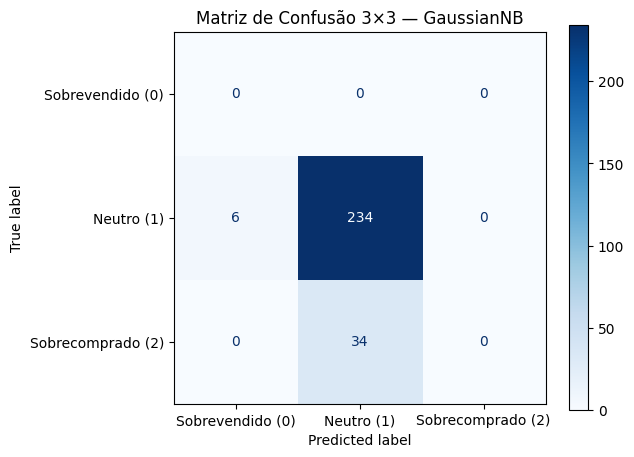

In [445]:
# Visualização gráfica formatada
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Matriz de Confusão 3×3 — GaussianNB", fontsize=12)
plt.grid(False)
plt.show()

In [446]:
# 4. Relatório de métricas por classe (Precision, Recall, F1-Score)
print("Relatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred, labels=[0, 1, 2], target_names=nomes_classes, digits=4, zero_division=0))

Relatório de Classificação Detalhado:
                   precision    recall  f1-score   support

 Sobrevendido (0)     0.0000    0.0000    0.0000         0
       Neutro (1)     0.8731    0.9750    0.9213       240
Sobrecomprado (2)     0.0000    0.0000    0.0000        34

         accuracy                         0.8540       274
        macro avg     0.2910    0.3250    0.3071       274
     weighted avg     0.7648    0.8540    0.8069       274



In [447]:
# Filtra apenas as amostras reais do conjunto de teste que pertencem às zonas extremas
mascara_extremas = (y_test == 0) | (y_test == 2)

total_extremos = mascara_extremas.sum()

if total_extremos > 0:
    acuracia_extremas = accuracy_score(y_test[mascara_extremas], y_pred[mascara_extremas])
    print(f"Total de ocorrências nas zonas extremas no teste: {total_extremos}")
    print(f"Acurácia nas Zonas Extremas (Classes 0 e 2): {acuracia_extremas:.2%}")
else:
    print("O conjunto de teste não contém registros nas zonas extremas.")

Total de ocorrências nas zonas extremas no teste: 34
Acurácia nas Zonas Extremas (Classes 0 e 2): 0.00%


**Observações:** Eu fiz a análise da tabela e detenho de dois pontos perante a essa acurárica deveras baixa de em torno de 85.40 %, o algoritmo além de receber poucos dados (por conta do período de cada dado ser semanal) e mesmo fazendo mais requisões, tem limites perante ao ativo que for escolher, no caso escolhi as cotações de ações da IBM, e notei na tabela que grande parte dela tinha o RSI neutro, ou seja, nem menor que 30 e nem maior que 70, fazendo com que o algoritmo preveja que a maior probabilidade da semana seguinte é a do RSI estar dentro da neutralidade.

In [448]:
print("=== RESULTADOS PROVA PRÁTICA 14 ===")
print(f"Acurácia Obtida: {accuracy_score(y_test, modelo_gnb.predict(X_test)):.4f}")

=== RESULTADOS PROVA PRÁTICA 14 ===
Acurácia Obtida: 0.8540
